# Extraction using new algo
1. Use class UmapAlgo to calculate all start points
2. Extract from -3000 step to +2000 step around start point
3. Store in such a way so that you can separate partial an full later
4. Save this local order data

In [1]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.analysis import AnalysisFunc
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
reader = DataRead()
analyse=AnalysisFunc()
algo = AlgoParFull()
algoumap=UmapAlgo()

#### To extract global order

In [ ]:
reader.new_algo_ext(25,"raw/workstation/tes_peri_go5.bz2","raw/workstation/tes_peri_lo5.bz2")

In [3]:
# check for already stored data
df_fn= reader.data_read_bz2("raw/workstation/tes_fn_go.bz2") 
#df_loc_fn = reader.data_read_bz2("raw/workstation/tes_fn_lo.bz2")

In [4]:
df_peri = reader.data_read_bz2("raw/workstation/tes_peri_go.bz2")
#df_loc_peri = reader.data_read_bz2("raw/workstation/tes_peri_lo.bz2")

In [6]:
df_fn_nc=reader.data_read_bz2("raw/workstation/tes_fn_nc.bz2")                                                                 

#### Visualize transition

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


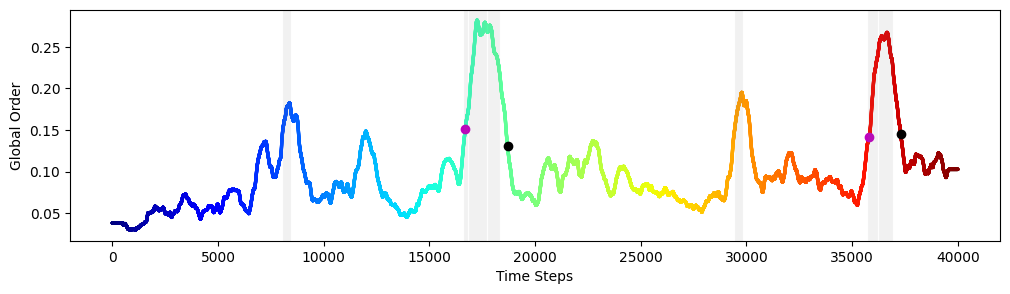

In [81]:
n=24
# find start stop points
pts=algoumap.compute_parameters(df_fn[n])
algoumap.plot_transition(df_fn[n],pts['start_points'],pts['stop_points'])

# for i in comm_pts['start_comm']:
#     plt.vlines(i,0,0.5, color='k')
# for i in comm_pts['stop_comm']:
#     plt.vlines(i,0,0.5, color='r')


# for i, threshold in enumerate(thresh_go):
#     if i==0:
#         plt.hlines(threshold,0,40000, color='m')
#     elif i==1:
#         plt.hlines(threshold,0,40000, color='c')
#     elif i==2:
#         plt.hlines(threshold,0,40000, color='y')
#     else:
#         plt.hlines(threshold,0,40000, color='g')


#### Find points where 90% of global order is crossed in a transition
- If transition never falls down, take the last timestep

In [82]:
def get_crossing_go(df, pts, n):
    """Get start and stop points where global order is 90%

    Args:
        df (dataframe): Global order dataframe of timesteps x iterations
        pts (dictionary): Start and Stop points of transition
        n (integer): Column number i.e iteration number

    Returns:
        dictionary: keys are 'start_comm' and 'stop_comm' with respective lists of points
    """
    # Ensure stop points match start points
    if len(pts['start_points']) > len(pts['stop_points']):
        pts['stop_points'].append(len(df[n]) - 1)

    _data = df[n].rolling(800, center=True).mean().ffill().bfill()
    start_comm=[]
    stop_comm=[]
    thresh_go=[]
    all_crossings = []
    for start, stop in zip(pts['start_points'], pts['stop_points']):
        #_data = df_fn[n].iloc[start:stop].rolling(800, center=True).mean().ffill().bfill()
        values = _data.iloc[start:stop].values
        window_values = values.copy()

        max_val = values.max()
        threshold = 0.90 * max_val
        thresh_go.append(threshold)
        above_threshold = window_values >= threshold

        # Detect transitions
        transitions = np.diff(above_threshold.astype(int))
        rising_edges = np.where(transitions == 1)[0]      # below → above
        falling_edges = np.where(transitions == -1)[0]     # above → below

        # Combine and sort all crossings
        #all_edges = np.sort(np.concatenate((rising_edges, falling_edges)))
        all_edges = np.concatenate((rising_edges, falling_edges))
        actual_indices = all_edges + start

        if len(actual_indices) > 0:
            all_crossings.extend(actual_indices)
            start_comm.append(actual_indices[0])
            # stop_comm.append(actual_indices[-1])
            if actual_indices[0]!=actual_indices[-1]:
                stop_comm.append(actual_indices[-1])
            elif stop==39999:
                # to take care of transitions which never fall back
                stop_comm.append(stop)
            else:
                # to take care of rolling window in the end cases
                print('this cell')
                stop_comm.append(stop+400)

            #print(f'Start {start} Stop {stop} Threshold {threshold}')
            #print(f'Crossing points (rising & falling): {actual_indices}')
        else:
            #print(f'No threshold crossing found between {start} and {stop}')
            closest_idx = np.argmin(np.abs(window_values - threshold))
            actual_idx = int(closest_idx) + start
            #print(f'Closest point to threshold at index: {actual_idx}')
            start_comm.append(start)
            stop_comm.append(stop)

    # print(f'\nTotal number of crossing points found: {len(all_crossings)}')
    # print(f' points {start_comm} ,{stop_comm}, {thresh_go}')
    
    return {'start_comm':start_comm,'stop_comm':stop_comm}

#### Using above function

In [83]:

pts=algoumap.compute_parameters(df_fn[n])

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [84]:
comm_pts=get_crossing_go(df_fn, pts, n)

In [85]:
comm_pts

{'start_comm': [17136, 36220], 'stop_comm': [18013, 36824]}

#### Get the binarized matrix
- columns arranged community wise

In [86]:
def get_binairized_matrix(df,trans_start):
    """Gives binarized matrix in desired order. YOu can uncomment plt lines to visualise the matrix.

    Args:
        df (dataframe): node community dataframe only transition part (5000x426)
        trans_start (int): starting point of transition
    Returns:
        dataframe: Binarized dataframe with community ordering
    """
    des_order=reader.get_communities()['des_order']
    mc = analyse.compute_main_cluster(df)
    nc_array = df.values
    nc=nc_array.copy()
    #print(mc)

    binary_mask = np.isclose(nc, mc)
    bm_ordered = binary_mask.T[des_order]

    df_bm=pd.DataFrame(bm_ordered).T
    #trans_start=pts['start_points'][0]
    df_bm.index=list(range(trans_start-3000,trans_start+2000))
    # plt.imshow(df_bm.T, cmap='gray', interpolation='nearest', aspect = 'auto')
    # plt.colorbar()
    # plt.title('Binarised matrix with community ordering')
    return df_bm

#### Checking above function

In [87]:
df_bm=get_binairized_matrix(df_fn_nc.loc[n].iloc[0:5000],pts['start_points'][0])

#### Get community percentage

In [102]:
def get_community_percentage(start,stop,df):
    """Calculates community percentage for a given transition

    Args:
        trans_start (int/float): starting point of transition
        start (int/float): 90% of global order timestep
        stop (int/float): If transition falls below 90% global order timestep
        df (dataframe): binarised node community dataframe only transition part (5000x426)
    """
    comm_count=reader.get_communities()['comm_val']
    comm_name=reader.get_communities()['name_seq']
    cum_count=np.cumsum(comm_count)
    # to store percentage and total count
    
    init=0
    if start in df.index and stop in df.index:
        
        # counting percentage in each community
        for count,name in zip(cum_count,comm_name):
            _array=df_bm.loc[start:stop,init:count].values
            tot=_array.size
            count_true=np.sum(_array)
            percentage=(count_true/tot)*100
            print(f'Community nodes {name} total {tot} from {init} to {count} : {percentage} %')
            
            init=count

    else:
        for count,name in zip(cum_count,comm_name):
            _array=df_bm.loc[start:,init:count].values
            print(f'case of stop outside nc')
            tot=_array.size
            count_true=np.sum(_array)
            percentage=(count_true/tot)*100
            print(f'Community nodes {name} total {tot} from {init} to {count} : {percentage} %')
            init=count
            
    

In [99]:


def get_community_percentage(start, stop, df_bm):
    """
    Calculates community-wise percentage for a given transition range.

    Args:
        start (int/float): starting timestep (e.g., 90% global order timestep)
        stop (int/float): ending timestep (e.g., below 90% global order timestep)
        df_bm (pd.DataFrame): binarised node-community dataframe (timesteps × nodes)
        
    """
    comm_count=reader.get_communities()['comm_val']
    comm_name=reader.get_communities()['name_seq']
    cum_count=np.cumsum(comm_count)

    # Define the time window (handle missing stop)
    if start not in df_bm.index:
        raise ValueError("Start index not found in dataframe")
    if stop in df_bm.index:
        df_slice = df_bm.loc[start:stop]
    else:
        df_slice = df_bm.loc[start:]
    
    results = []

    init = 0
    for count, name in zip(cum_count, comm_name):
        sub_array = df_slice.iloc[:, init:count].values
        tot=sub_array.size
        count_true=np.sum(sub_array)
        percentage=(count_true/tot)*100
        results.append({
            "community": name,
            "total": tot,
            "percentage": percentage
        })
        init = count
    df=pd.DataFrame(results)
    df=df.set_index('community')
    return df


#### Check community percentage

In [104]:
get_community_percentage( comm_pts['start_comm'][0], comm_pts['stop_comm'][0], df_bm)

Community nodes MO total 50046 from 0 to 56 : 22.80302122047716 %
Community nodes VIS total 44778 from 56 to 106 : 17.861449819107598 %
Community nodes ORB total 30730 from 106 to 140 : 33.33224861698666 %
Community nodes HTh total 39510 from 140 to 184 : 14.550746646418627 %
Community nodes OLF total 32486 from 184 to 220 : 76.60530690143446 %
Community nodes HIPP total 44778 from 220 to 270 : 18.037875742552146 %
Community nodes MID total 62338 from 270 to 340 : 6.459944175302383 %
Community nodes HIND total 75508 from 340 to 426 : 0.4092281612544367 %


In [101]:
get_community_percentage( comm_pts['start_comm'][0], comm_pts['stop_comm'][0], df_bm)

,total,percentage
community,,
MO,49168,22.870566
VIS,43900,18.027335
ORB,29852,33.016213
HTh,38632,13.292089
OLF,31608,77.866363
HIPP,43900,18.398633
MID,61460,6.552229
HIND,75508,0.409228


In [96]:
df=df_gc.copy()
weighted_avg = (df['percentage'] * df['total']).sum() / df['total'].sum()
print(f"Weighted Average Percentage = {weighted_avg:.4f}%")

Weighted Average Percentage = 19.0293%


In [ ]:
# full network
param_fn=algo.compute_param_df(df_fn)

In [ ]:
param_fn[0]

{'n_part': 20,
 'n_full': 10,
 'n_total': 30,
 'itr_tran': [0,
  1,
  2,
  5,
  6,
  7,
  8,
  10,
  11,
  12,
  13,
  14,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24]}

In [ ]:
param_peri = algo.compute_param_df(df_peri)

In [ ]:
param_peri[0]

{'n_part': 18,
 'n_full': 5,
 'n_total': 23,
 'itr_tran': [4, 5, 6, 10, 11, 12, 13, 14, 15, 17, 19, 21, 22, 23, 24]}

In [ ]:
pts=algoumap.compute_parameters(df_peri[5])
# algoumap.plot_transition()

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
algoumap.plot_transition(df_peri[5],pts['start_points'],pts['stop_points'])

In [ ]:
df_loc_peri.loc[5].iloc[0:426]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.167406,0.176834,0.186374,0.195959,0.205529,0.215028,0.224408,0.233623,0.242636,0.251413,...,0.472650,0.470164,0.467538,0.464771,0.461860,0.458803,0.455593,0.452228,0.448702,0.445009
1,0.105868,0.109681,0.113445,0.117153,0.120795,0.124365,0.127856,0.131263,0.134582,0.137809,...,0.175068,0.171374,0.167580,0.163687,0.159696,0.155610,0.151431,0.147161,0.142804,0.138365
2,0.116790,0.121040,0.125228,0.129341,0.133367,0.137294,0.141110,0.144806,0.148372,0.151799,...,0.258484,0.255481,0.252405,0.249259,0.246047,0.242771,0.239437,0.236049,0.232612,0.229132
3,0.290160,0.297788,0.305172,0.312307,0.319187,0.325805,0.332153,0.338223,0.344005,0.349492,...,0.184771,0.177926,0.170925,0.163785,0.156525,0.149169,0.141741,0.134276,0.126811,0.119395
4,0.065031,0.069161,0.073223,0.077214,0.081130,0.084967,0.088722,0.092390,0.095969,0.099454,...,0.218597,0.211916,0.205196,0.198448,0.191678,0.184895,0.178110,0.171331,0.164569,0.157836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.166991,0.176487,0.186035,0.195595,0.205130,0.214611,0.224013,0.233314,0.242493,0.251534,...,0.360159,0.357768,0.355030,0.351970,0.348617,0.344997,0.341140,0.337075,0.332832,0.328443
422,0.219830,0.225141,0.230379,0.235518,0.240534,0.245405,0.250109,0.254630,0.258950,0.263057,...,0.097852,0.095687,0.093505,0.091306,0.089094,0.086871,0.084638,0.082398,0.080153,0.077907
423,0.127429,0.128883,0.130336,0.131787,0.133236,0.134683,0.136127,0.137566,0.138999,0.140425,...,0.118697,0.115352,0.112288,0.109552,0.107192,0.105249,0.103761,0.102755,0.102253,0.102262
424,0.198280,0.206980,0.215491,0.223796,0.231882,0.239735,0.247342,0.254692,0.261775,0.268582,...,0.142422,0.136249,0.129825,0.123165,0.116281,0.109189,0.101909,0.094460,0.086870,0.079171


In [ ]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2)

ax1.plot(analyse.smooth(df_peri[5].iloc[pts['start_points'][0]-3000:pts['start_points'][0]+2000])) 
ax3.imshow(df_loc_peri.loc[5].iloc[0:426],aspect='auto',cmap='Reds')

ax2.plot(analyse.smooth(df_peri[5].iloc[pts['start_points'][1]-3000:pts['start_points'][1]+2000])) 
ax4.imshow(df_loc_peri.loc[5].iloc[426:852],aspect='auto',cmap='Reds')

In [ ]:
## node community extraction
reader.ext_node_community(df_loc_fn,0.5,"raw/workstation/tes_fn_nc.bz2")

#### Checking node community data

In [5]:
df_fn_nc = reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')
df_peri_nc = reader.data_read_bz2('raw/workstation/tes_peri_nc.bz2')

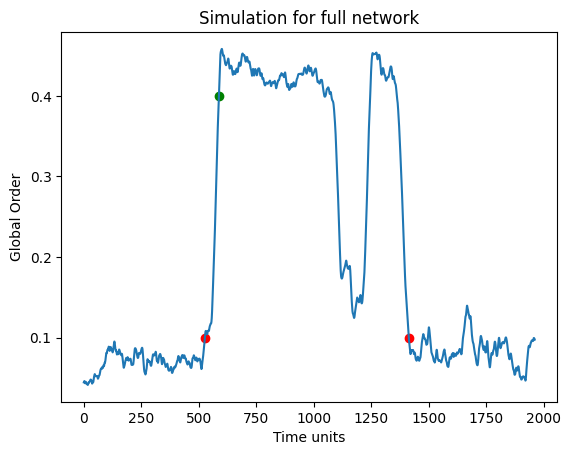

In [13]:
n=10
analyse.plot_global_synchrony(df_peri[n],0.05)

In [14]:
df_peri_nc.loc[n].shape


(10000, 426)

1


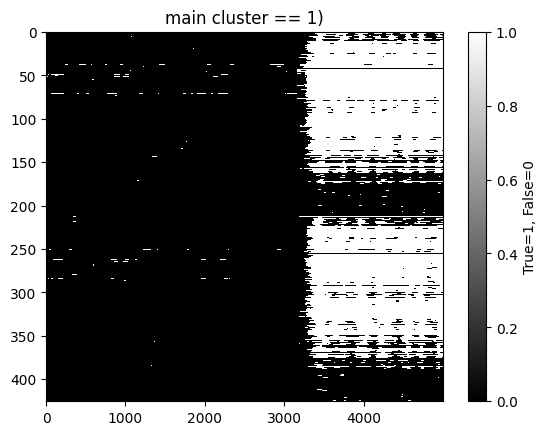

In [15]:

nc_array = df_peri_nc.loc[n].iloc[0:5000].values
nc=nc_array.copy()
mc = analyse.compute_main_cluster(df_peri_nc.loc[n].iloc[0:5000])
print(mc)

binary_mask = np.isclose(nc, mc)

# Visualize binary mask
plt.imshow(binary_mask.T, cmap='gray', interpolation='nearest', aspect = 'auto')
plt.title(f"main cluster == {mc})")
plt.colorbar(label='True=1, False=0')
plt.show()

In [7]:
bm=binary_mask.T
id=bm[:,3999]
s_r=bm[id,:]

In [8]:
row_numbers = np.where(bm[:, 3999])[0]

In [9]:
row_numbers

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 144, 145,
       146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 158, 159,
       160, 161, 162, 166, 167, 168, 173, 174, 190, 213, 214, 215, 216,
       217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 22

In [30]:
#Map rows to community

comm_dict=reader.get_communities()

In [31]:
l_communities=reader.data_read_pkl("connectivity_matrix/mb_communities_dict.pickle")

In [32]:
community_names = {
        0: "MO",
        1: "MID",
        2: "VIS",
        3: "ORB",
        4: "HTh",
        5: "HIND",
        6: "OLF",
        7: "HIPP",
    }
communities = {community_names[i]: v for i, v in l_communities.items()}

In [28]:
df_comm_map=comm_dict['comm_map']

In [37]:
comm_dict['comm_val']

MO      56
VIS     50
ORB     34
HTh     44
OLF     36
HIPP    50
MID     70
HIND    86
dtype: int64

In [18]:
df_comm_map.index

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            416, 417, 418, 419, 420, 421, 422, 423, 424, 425],
           dtype='int64', length=426)

In [49]:
mo_c=0
vis_c=0
orb_c=0
hth_c=0
olf_c=0
hipp_c=0
mid_c=0
hind_c=0


for element in  row_numbers:
    if element in communities['MO']:
        mo_c+=1
    elif element in communities['VIS']:
        vis_c+=1
    elif element in communities['ORB']:
        orb_c+=1
    elif element in communities['HTh']:
        hth_c+=1
    elif element in communities['OLF']:
        olf_c+=1    
    elif element in communities['HIPP']:
        hipp_c+=1
    elif element in communities['MID']:
        mid_c+=1    
    elif element in communities['HIND']:
        hind_c+=1   
        
comm_name = comm_dict['comm_val'].index.tolist()
comm_count=dict(zip(comm_name,[mo_c,vis_c,orb_c,hth_c,olf_c,hipp_c,mid_c,hind_c]))
per_comm={}
for name, total in comm_dict['comm_val'].items():
    print(f'{name} {(comm_count[name]/total)*100}%')
    per_comm[f'{name}']=(comm_count[name]/total)*100



MO 100.0%
VIS 100.0%
ORB 100.0%
HTh 97.72727272727273%
OLF 94.44444444444444%
HIPP 100.0%
MID 85.71428571428571%
HIND 4.651162790697675%


In [50]:
per_comm

{'MO': 100.0,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 97.72727272727273,
 'OLF': 94.44444444444444,
 'HIPP': 100.0,
 'MID': 85.71428571428571,
 'HIND': 4.651162790697675}

In [51]:
mc = analyse.compute_main_cluster(df_fn_nc.loc[n])

In [64]:
n=2
df_fn_nc.loc[2].shape

(10000, 426)

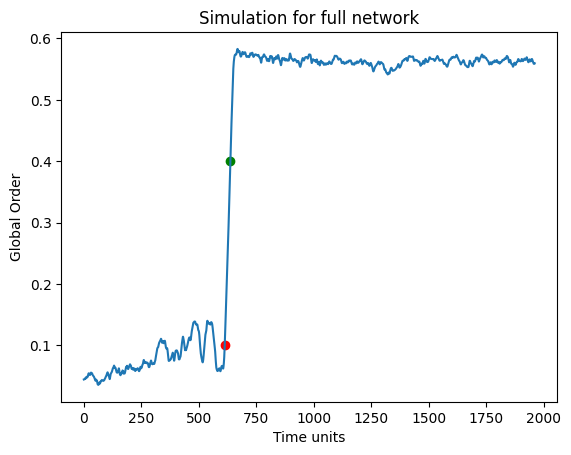

In [27]:
n=1
analyse.plot_global_synchrony(df_fn[n],0.05)

In [34]:
n=10
mc=analyse.compute_main_cluster(df_peri_nc.loc[n].iloc[0:5000])
nc=df_peri_nc.loc[n].iloc[0:5000].values
get_node(nc, mc)

{'MO': 82.14285714285714,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 100.0,
 'OLF': 91.66666666666666,
 'HIPP': 92.0,
 'MID': 74.28571428571429,
 'HIND': 3.488372093023256}

In [17]:
def get_node(nc_array,mc):
    nc=nc_array.copy()
    
    binary_mask = np.isclose(nc, mc)
    bm=binary_mask.T
    row_numbers = np.where(bm[:, 3999])[0]

    mo_c=0
    vis_c=0
    orb_c=0
    hth_c=0
    olf_c=0
    hipp_c=0
    mid_c=0
    hind_c=0


    for element in  row_numbers:
        if element in communities['MO']:
            mo_c+=1
        elif element in communities['VIS']:
            vis_c+=1
        elif element in communities['ORB']:
            orb_c+=1
        elif element in communities['HTh']:
            hth_c+=1
        elif element in communities['OLF']:
            olf_c+=1    
        elif element in communities['HIPP']:
            hipp_c+=1
        elif element in communities['MID']:
            mid_c+=1    
        elif element in communities['HIND']:
            hind_c+=1   
            
    
   
    
    comm_name = comm_dict['comm_val'].index.tolist()
    comm_count=dict(zip(comm_name,[mo_c,vis_c,orb_c,hth_c,olf_c,hipp_c,mid_c,hind_c]))
    per_comm={}
    for name, total in comm_dict['comm_val'].items():
        #print(f'{name} {(comm_count[name]/total)*100}%')
        per_comm[f'{name}']=(comm_count[name]/total)*100
        
    return per_comm
    

In [55]:
get_node(nc, mc)

MO 100.0%
VIS 100.0%
ORB 100.0%
HTh 97.72727272727273%
OLF 94.44444444444444%
HIPP 100.0%
MID 85.71428571428571%
HIND 4.651162790697675%


{'MO': 100.0,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 97.72727272727273,
 'OLF': 94.44444444444444,
 'HIPP': 100.0,
 'MID': 85.71428571428571,
 'HIND': 4.651162790697675}

In [41]:
comm_count

{'MO': 56,
 'VIS': 50,
 'ORB': 34,
 'HTh': 43,
 'OLF': 34,
 'HIPP': 50,
 'MID': 60,
 'HIND': 4}

In [38]:
comm_dict['comm_val'].index.tolist()

['MO', 'VIS', 'ORB', 'HTh', 'OLF', 'HIPP', 'MID', 'HIND']